In [16]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import erf
from qiskit import QuantumRegister, QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT
from qiskit.circuit.library.arithmetic.piecewise_chebyshev import PiecewiseChebyshev


In [17]:
def forcing(x, alpha0=0.3, alpha1=0.1, alpha2=-0.1772):
    """Forcing function f(x)"""
    return np.exp(-(x-alpha0)**2/alpha1**2) + alpha2

def solutionAnalytic(x, alpha0=0.3, alpha1=0.1, alpha2=-0.1772, C1=-0.05315095, C0=0.02318584):
    """
    Analytic solution of -v'' = f with periodic BC (v(0)=v(L)) and zero-mean
    condition (mean(v)=0), matching the periodic solvability requirement
    on f (alpha2 is tuned so that mean(f) ~ 0 over [0,1]).

    C1, C0 were derived by solving:
      v(x) = -S0(x) + C1*x + C0
    where S0'' = f, subject to v(0)=v(L) and integral(v) = 0.
    """
    S0 = 0.5*alpha1*np.sqrt(np.pi)*((x-alpha0)*erf((x-alpha0)/alpha1)
         + (alpha1/np.sqrt(np.pi))*np.exp(-(x-alpha0)**2/alpha1**2)) + 0.5*alpha2*x**2
    return -S0 + C1*x + C0

def r_index(k, N):
    """Fold frequency index k in [0,N) to r in [-N/2, N/2)"""
    return np.where(k < N//2, k, k - N)

def poisson_scaling(k, N, L):
    """Spectral Green's function for -v''=f with periodic BC: 1/(2*pi*r/L)^2"""
    r = r_index(k, N)
    r = np.where(r == 0, np.inf, r)  # r=0 (DC mode) excluded -- solvability sets it to 0 amplitude
    return (L / (2*np.pi*r))**2

def break_points_pwc_symmetric(n_pts, eps=1e-6):
    """
    Dyadic breakpoints for piecewise-Chebyshev fit of poisson_scaling.
    poisson_scaling has singularities at BOTH k->0 and k->n_pts (after folding),
    so breakpoints are densified symmetrically at both ends of the spectrum.
    """
    pt = n_pts // 2
    left = []
    while pt > 1:
        pt = pt // 2
        left.append(pt - eps)
    left = left[::-1]                      # ascending, dense near 0
    mid = (n_pts/2) - eps
    right = [n_pts - x for x in left][::-1]  # mirrors density near n_pts
    return left + [mid] + right + [n_pts - eps]


C:\Users\saisr\AppData\Local\Temp\ipykernel_15352\1499609242.py:24: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(num_qubits=n, inverse=False).to_gate()


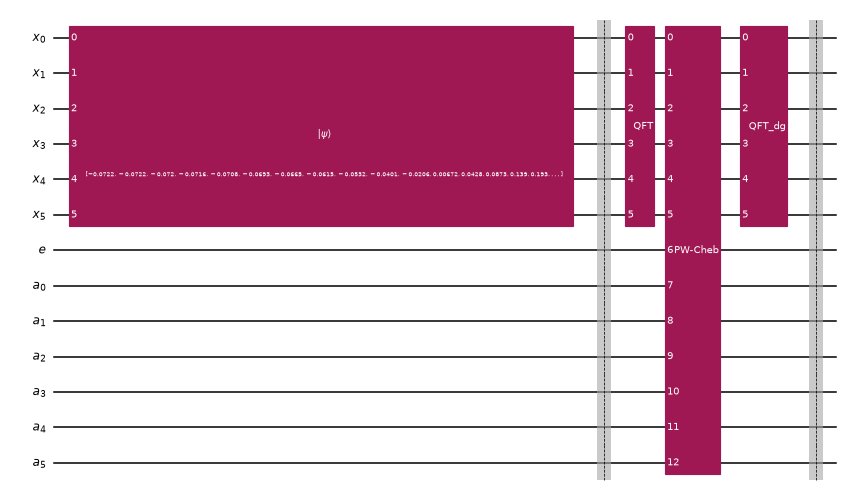

In [ ]:
# ---------------- circuit parameters ----------------
N = 64
n = int(np.log2(N))

L = 1
h = 1/N
x = np.linspace(0, L-h, N)

degree = 3

# ---------------- amplitude encode the forcing ----------------
f_i = forcing(x)
f = f_i / np.linalg.norm(f_i)

qcs = QuantumRegister(n, "x")   # spatial discretisation qubits
qce = QuantumRegister(1, "e")   # ancilla / rotation-flag qubit (from PiecewiseChebyshev)
qca = QuantumRegister(n, "a")   # ancilla qubits used by PiecewiseChebyshev
qc = QuantumCircuit(qcs, qce, qca)

qc.initialize(f, list(range(n)))
qc.barrier()

# ---------------- QFT ----------------
qft = QFT(num_qubits=n, inverse=False).to_gate()
qc.append(qft, list(range(n)))

# ---------------- piecewise-Chebyshev spectral filter (1/k^2 Green's function) ----------------
poisson_scale = lambda k: poisson_scaling(k, N, L)   # MUST be callable, not a precomputed array
breakpoints = break_points_pwc_symmetric(N)          # covers BOTH spectral singularities

pw_approximation = PiecewiseChebyshev(poisson_scale, degree, breakpoints, n)
pw_approximation._build()
pw_gate = pw_approximation.to_instruction()
pw_gate.label = "PW-Cheb"
qc.append(pw_gate, list(range(2*n + 1)))

# ---------------- inverse QFT ----------------
qc.append(qft.inverse(), list(range(n)))
qc.barrier()

qc.draw("mpl", scale=0.55)


In [19]:
# ---------------- extract result: post-select e=1, a=0...0 ----------------
sv = Statevector(qc)
data = sv.data

e_idx = n
a_start = n + 1

all_idx = np.arange(len(data))
e_bits = (all_idx >> e_idx) & 1
a_bits = np.zeros_like(all_idx)
for qb in range(a_start, a_start + n):
    a_bits |= (((all_idx >> qb) & 1) << (qb - a_start))

mask = (e_bits == 1) & (a_bits == 0)
post_selected = data[mask]
success_prob = np.sum(np.abs(post_selected)**2)
print(f"Success probability (e=1, a=0): {success_prob:.6e}")

assert len(post_selected) == 2**n, (
    f"Expected {2**n} amplitudes, got {len(post_selected)} -- "
    "a-register did not fully uncompute to 0, check circuit construction"
)

psi_x = post_selected / np.sqrt(success_prob)


Success probability (e=1, a=0): 3.652750e-04


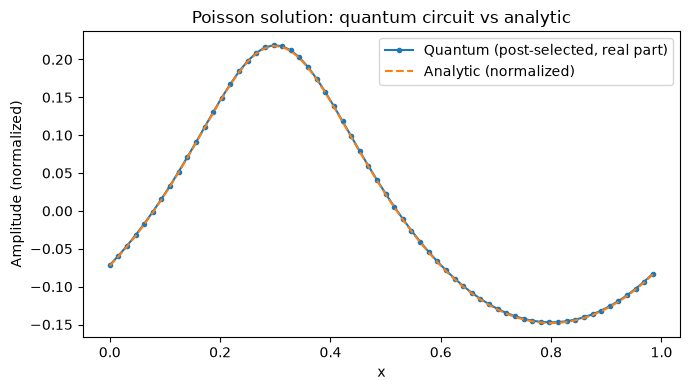

In [20]:
# ---------------- compare against analytic solution ----------------
analytic = solutionAnalytic(x)
analytic_normalized = analytic / np.linalg.norm(analytic)

plt.figure(figsize=(7, 4))
plt.plot(x, np.real(psi_x), "o-", label="Quantum (post-selected, real part)", markersize=3)
plt.plot(x, analytic_normalized, "--", label="Analytic (normalized)")
plt.xlabel("x")
plt.ylabel("Amplitude (normalized)")
plt.legend()
plt.title("Poisson solution: quantum circuit vs analytic")
plt.tight_layout()
plt.show()
